**Українська версія:**      
Щоб побудувати та визначити модель, яка забезпечує найнадійніші прогнози відтоку клієнтів, буде навчено, оцінено та збережено п'ять моделей: **логістичну регресію, дерево рішень, випадковий ліс, метод опорних векторів (SVM) та нейронну мережу**. Моделі представлені у порядку зростання складності — починаючи з логістичної регресії як інтерпретованої базової моделі, і завершуючи нейронною мережею. Усі п'ять моделей буде порівняно за однаковим набором метрик (Accuracy, Precision, Recall, F1-score), після чого модель з найкращими результатами буде обрана як фінальна — проте інші моделі також залишаться прийнятними варіантами залежно від конкретного балансу між інтерпретованістю, швидкістю та точністю, який потрібен у певній ситуації.

**English version:**       
In order to build and identify the model that delivers the most reliable churn predictions, five models will be trained, evaluated, and saved: **Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, and a Neural Network**. The models are presented in increasing order of complexity, starting with Logistic Regression as an interpretable baseline and finishing with a Neural Network. All five will be compared using the same set of metrics (Accuracy, Precision, Recall, F1-score), after which the best-performing model will be selected as the final choice — though the remaining models will also remain valid options depending on the specific trade-off between interpretability, speed, and accuracy required. 

In [195]:
import os
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, classification_report, hinge_loss, ConfusionMatrixDisplay, RocCurveDisplay,roc_curve, roc_auc_score

import tensorflow as tf

from keras import models
from keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

In [2]:
df = pd.read_csv('../data/processed/df_cleaned.csv')
df

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,has_contract_info,has_active_contract
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,1,1
1,0,0,8.22,0,0.00,0,0.0,0.0,0,1,0,0
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,1,0
3,0,0,6.87,21,0.00,1,0.0,0.0,0,1,0,0
4,0,0,6.39,0,0.00,0,0.0,0.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1,1,0.09,0,1.25,0,0.0,0.0,0,1,1,1
72270,1,0,0.06,1,1.63,0,0.8,0.0,0,1,1,1
72271,1,0,0.02,0,2.19,0,1.5,0.2,0,1,1,1
72272,0,0,0.01,0,0.72,0,0.0,0.0,0,1,1,1


In [3]:
X = df.drop(columns=['churn'])
y = df['churn']

In [4]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=19)

**Українська версія:**     
Усі п'ять моделей навчаються на одному й тому самому стандартизованому наборі ознак, а не з вибірковим масштабуванням для кожної моделі окремо. Хоча стандартизація не є строго обов'язковою для деревоподібних моделей (дерево рішень, випадковий ліс), оскільки їхні розділення базуються на порогових порівняннях і тому не залежать від масштабу ознак, уніфіковане застосування спрощує пайплайн і усуває ризик випадково подати не той варіант даних не тій моделі. Для SVM та нейронної мережі стандартизація є необхідною, оскільки ці моделі за своєю природою чутливі до масштабу ознак. Для логістичної регресії масштабування не є математично обов'язковим для нерегуляризованої моделі, проте є усталеною доброю практикою: воно забезпечує справедливе застосування L2-регуляризації незалежно від початкового масштабу ознак і покращує збіжність оптимізатора — обидва фактори зазвичай призводять до кращої, точнішої моделі на практиці.

**English version:**    
All five models are trained on the same standardized feature set, rather than applying scaling selectively per model. While standardization is not strictly required for tree-based models (Decision Tree, Random Forest), since their splits are based on threshold comparisons and are therefore scale-invariant, applying it uniformly simplifies the pipeline and eliminates the risk of accidentally feeding the wrong data version to the wrong model. For SVM and the Neural Network, standardization is essential, as these models are inherently sensitive to feature scale. For Logistic Regression, scaling is not mathematically required for an unregularized model, but it is standard best practice: it ensures L2 regularization penalizes features fairly regardless of their original scale, and it improves solver convergence — both of which typically lead to a better-fitted, more accurate model in practice.

In [5]:
# Українська версія: Стандартизація оброблюваних даних
# English version: Standartization of processed data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1. Модель логістичної регресії (Logistic Regression Model)

In [6]:
num_cycle = 0

In [8]:
dict_all_best_params_per_step = {}
all_metrics_per_step = {}

In [43]:
# Українська версія: Визначення типу моделі, параметрів та класифікатора.
# English version: Definition of the model type, parameters and classifier. 
model_lg = LogisticRegression(solver='saga',max_iter=5000,random_state=19)


parameters = [
    {
        'C': [5,7,7.2,7.5,7.6],
        'penalty': ['l1', 'l2'],
        'class_weight':['balanced', None]     
    },
]

clf = GridSearchCV(estimator=model_lg,param_grid=parameters)
num_cycle += 1

**Українська версія:**     
Щоб знайти оптимальне значення C, буде протестовано кілька значень навколо поточного найкращого параметра (C=10). Усі попередньо протестовані комбінації параметрів зберігаються у `dict_all_best_params_per_step`, щоб уникнути повторного проведення експериментів.

**English version:**  
To find the optimal value of C, several values around the temporary best parameter will be tested. The previously tested parameter combinations are saved in `dict_all_best_params_per_step` to avoid repeating experiments.

In [44]:
# Train model
clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_lg = clf.predict(X_test_scaled)

# Accuracy score
acc_lg = accuracy_score(y_pred_lg, y_test)

# Loss score
y_pred_proba_lg = clf.predict_proba(X_test_scaled)[:,1]
loss_lg = log_loss(y_test,y_pred_proba_lg)

In [66]:
class_rep_lr_dict = classification_report(y_test, y_pred_lg,output_dict=True)
class_rep_lr_str = classification_report(y_test, y_pred_lg,output_dict=False)


print('Показник точності логістичної регресії: ', acc_lg)
print('Показник втрат у логістичній регресії: ', loss_lg)
print('\t\tПідсумкова оцінка моделі:')
# print('Accuracy score of Logistic Regression: ', acc_lg)
# print('Loss score of Logistic Regression: ', loss_lg)

print(class_rep_lr_str)

Показник точності логістичної регресії:  0.9236250432376341
Показник втрат у логістичній регресії:  0.23644608009457616
		Підсумкова оцінка моделі:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6445
           1       0.95      0.91      0.93      8010

    accuracy                           0.92     14455
   macro avg       0.92      0.93      0.92     14455
weighted avg       0.93      0.92      0.92     14455



**Українська версія:**     
Позитивні показники відтоку клієнтів, розраховані за допомогою логістичної регресії, додаються до кінцевого масиву даних для остаточної оцінки (`final_comparison_churn_df`)

**English version:**      
The positive churn metrics of Logistic Regression are added to the final dataframe for final evaluation (`final_comparison_churn_df`)

In [96]:
precision_churn = class_rep_lr_dict['1']['precision']
recall_churn = class_rep_lr_dict['1']['recall']
f1_churn = class_rep_lr_dict['1']['f1-score']

final_comparison_churn_df = pd.DataFrame({'Metrics':['Accuracy', 'Loss','Precision','Recall','F1-Score'],
                                          'best_logistic_regression_model': [acc_lg,loss_lg,precision_churn,recall_churn,
                                                                             f1_churn]})
final_comparison_churn_df

,Metrics,best_logistic_regression_model
0,Accuracy,0.923625
1,Loss,0.236446
2,Precision,0.952437
3,Recall,0.907491
4,F1-Score,0.929421


**Українська версія:**     
Негативні показники відтоку клієнтів, розраховані за допомогою логістичної регресії, додаються до кінцевого масиву даних для остаточної оцінки (`final_comparison_no_churn_df`)

**English version:**      
The negative churn metrics of Logistic Regression are added to the final dataframe for final evaluation (`final_comparison_no_churn_df`)

In [72]:
precision_no_churn = class_rep_lr_dict['0']['precision']
recall_no_churn = class_rep_lr_dict['0']['recall']
f1_no_churn = class_rep_lr_dict['0']['f1-score']

final_comparison_no_churn_df = pd.DataFrame({'Metrics':['Accuracy', 'Loss','Precision','Recall','F1-Score'],
                                          'best_logistic_regression_model': [acc_lg,loss_lg,precision_no_churn,recall_no_churn,
                                                                             f1_no_churn]})
final_comparison_no_churn_df

,Metrics,best_logistic_regression_model
0,Accuracy,0.923625
1,Loss,0.236446
2,Precision,0.891397
3,Recall,0.943677
4,F1-Score,0.916792


**Українська версія:**     
Макросередні показники класифікації моделі логістичної регресії додаються до кінцевої таблиці даних для порівняння (`final_comparison_macro_df`) з метою остаточної оцінки. 

**English version:**      
The macro-average classification metrics of the Logistic Regression model are added to the final comparison dataframe (`final_comparison_macro_df`) for final evaluation.

In [73]:
macro_precision_lg = class_rep_lr_dict['macro avg']['precision']
macro_recall_lg = class_rep_lr_dict['macro avg']['recall']
macro_f1_lg = class_rep_lr_dict['macro avg']['f1-score']

final_comparison_macro_df = pd.DataFrame({'Metrics':['Accuracy', 'Loss','Precision','Recall','F1-Score'],
                                          'best_logistic_regression_model': [acc_lg,loss_lg,macro_precision_lg,macro_recall_lg,
                                                                             macro_f1_lg]})
final_comparison_macro_df

,Metrics,best_logistic_regression_model
0,Accuracy,0.923625
1,Loss,0.236446
2,Precision,0.921917
3,Recall,0.925584
4,F1-Score,0.923107


In [106]:
## Українська версія: Збереження найкращих параметрів та найкращої моделі
## English version: Saving the best parameters and the best model


best_params = clf.best_params_
best_estimator = clf.best_estimator_
dict_all_best_params_per_step[f'{num_cycle}_cycle'] = best_params
all_metrics_per_step[f'{num_cycle}_cycle'] = class_rep_lr

print('Найкращі параметри: ', best_params)
print('Найкраща логістична модель: ', best_estimator)
# print('Best parameters are: ', best_params)
# print('Best logistic model is: ', best_estimator)

Найкращі параметри:  {'C': 7.5, 'class_weight': None, 'penalty': 'l2'}
Найкраща логістична модель:  LogisticRegression(C=7.5, max_iter=5000, random_state=19, solver='saga')


In [77]:
## Українська версія: Збереження моделі у папці logistic_regression
## English version: Saving the model to the logistic_regression folder

logistic_models_location = '../models/logistic_regression'

os.makedirs(logistic_models_location, exist_ok=True)

model_path = os.path.join(logistic_models_location, 'best_logistic_regression_model.pkl')

joblib.dump(best_estimator,model_path)

['../models/logistic_regression/best_logistic_regression_model.pkl']

### 2. Модель «дерево рішень» (The Decision Tree Model)

In [97]:
# 1. Українська версія: Ініціалізувати модель
#    English version: Initialize the model

decision_tree_model = DecisionTreeClassifier(random_state=19)

# 2. Українська версія: Вибір параметрів
#    English version: Parameter selection

param_grid = {
    'criterion': ['entropy'],
    'max_depth': [8,9,10],
    'min_samples_leaf': [2,3, 4]
}
# 3. Українська версія: Classificator
#    English version: Класифікатор

clf_dt = GridSearchCV(estimator=decision_tree_model,param_grid=param_grid,cv=10)

# 4. Українська версія: Навчання
#    English version: Fitting

clf_dt.fit(X_train_scaled, y_train)

# 5. Українська версія: Прогнози
#    English version: Predictions
y_pred_dt = clf_dt.predict(X_test_scaled)

In [98]:
# 6. Українська версія: Точність та інші показники
#    English version: Accuracy and other metrics

acc_dt = accuracy_score(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt,output_dict=True)
class_report_dt_str = classification_report(y_test, y_pred_dt)

In [107]:
acc_dt_rounded = round(acc_dt * 100, 2)
# print(f'The accuracy score of the Decision Tree model is {acc_dt_rounded}% ({acc_dt})')
print(f'Показник точності моделі «дерево рішень є {acc_dt_rounded}% ({acc_dt})')
print('\t\t')
print('\t\tПідсумкова оцінка моделі «дерева рішень»:')
print(class_report_dt_str)

Показник точності моделі «дерево рішень є 93.93% (0.9392597717052923)
		
		Підсумкова оцінка моделі «дерева рішень»:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6445
           1       0.96      0.93      0.94      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



**Українська версія:**     
Позитивні показники відтоку клієнтів за моделлю «Дерево рішень» додаються до кінцевого масиву даних для остаточної оцінки (`final_comparison_churn_df`)

**English version:**      
The positive churn metrics of the Decision Tree model is added to the final dataframe for final evaluation (`final_comparison_churn_df`)

In [123]:
precision_churn_dt = class_report_dt['1']['precision']
recall_churn_dt = class_report_dt['1']['recall']
f1_churn_dt = class_report_dt['1']['f1-score']

final_comparison_churn_df['best_decision_tree_model'] = [acc_dt,None,precision_churn_dt,recall_churn_dt,
                                                                             f1_churn_dt]
final_comparison_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.940989
1,Loss,0.236446,NaN,NaN
2,Precision,0.952437,0.956828,0.957199
3,Recall,0.907491,0.932459,0.935331
4,F1-Score,0.929421,0.944487,0.946139


**Українська версія:**     
Негативні показники відтоку клієнтів, розраховані за моделлю «Дерево рішень», додаються до кінцевого масиву даних (`final_comparison_no_churn_df`) для остаточної оцінки 

**English version:**      
The negative churn metrics of the Decision Tree model are added to the final dataframe (`final_comparison_no_churn_df`) for final evaluation

In [124]:
precision_no_churn_dt = class_report_dt['0']['precision']
recall_no_churn_dt = class_report_dt['0']['recall']
f1_no_churn_dt = class_report_dt['0']['f1-score']

final_comparison_no_churn_df['best_decision_tree_model'] = [acc_dt,None,precision_no_churn_dt,recall_no_churn_dt,
                                                                             f1_no_churn_dt]
final_comparison_no_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.940989
1,Loss,0.236446,NaN,NaN
2,Precision,0.891397,0.918634,0.921847
3,Recall,0.943677,0.947711,0.948022
4,F1-Score,0.916792,0.932946,0.934751


**Українська версія:**     
Макросередні показники класифікації моделі «Дерево рішень» додаються до кінцевої таблиці даних для порівняння (`final_comparison_macro_df`) з метою остаточної оцінки. 

**English version:**      
The macro-average classification metrics of the Decision Tree model are added to the final comparison dataframe (`final_comparison_macro_df`) for final evaluation.

In [125]:
macro_precision_dt = class_report_dt['macro avg']['precision']
macro_recall_dt = class_report_dt['macro avg']['recall']
macro_f1_dt = class_report_dt['macro avg']['f1-score']

final_comparison_macro_df['best_decision_tree_model'] = [acc_dt,None,macro_precision_dt,macro_recall_dt,
                                                                             macro_f1_dt]
final_comparison_macro_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.940989
1,Loss,0.236446,NaN,NaN
2,Precision,0.921917,0.937731,0.939523
3,Recall,0.925584,0.940085,0.941676
4,F1-Score,0.923107,0.938716,0.940445


In [109]:
## Українська версія: Збереження найкращих параметрів та найкращої моделі
## English version: Saving the best parameters and the best model 

best_params_dt = clf_dt.best_params_
best_estimator_dt = clf_dt.best_estimator_

print('Найкращі параметри: ', best_params_dt)
print('Найкраща модель «дерева рішень»: ', best_estimator_dt)

# print('Best parameters are: ', best_params_dt)
# print('Best logistic model is: ', best_estimator_dt)

Найкращі параметри:  {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 3}
Найкраща модель «дерева рішень»:  DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_leaf=3,
                       random_state=19)


If time allows, build a visual graphic

In [111]:
decision_tree_location = '../models/decision_tree'

os.makedirs(decision_tree_location, exist_ok=True)

model_path = os.path.join(decision_tree_location, 'best_decision_tree_model.pkl')

joblib.dump(best_estimator_dt,model_path)

['../models/decision_tree/best_decision_tree_model.pkl']

### 3. Модель «Випадковий ліс» (The Random Forest Model)

In [111]:
num_steps_rf = 0
dict_all_best_params_per_step_rf = {}
all_metrics_per_step_rf = {}

In [142]:
# 1. Українська версія: Ініціалізувати модель
#    English version: Initialize the model

random_forest_model = RandomForestClassifier(random_state=19)

# 2. Українська версія: Вибір параметрів
#    English version: Parameter selection

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf':[2,4,6,8],
    'max_features': [None,'sqrt', 'log2']
}

# 3. Українська версія: Classificator
#    English version: Класифікатор

clf_rf = GridSearchCV(estimator=random_forest_model,param_grid=param_grid,cv=10)
num_steps_rf += 1

# 4. Українська версія: Навчання
#    English version: Fitting

clf_rf.fit(X_train_scaled, y_train)

# 5. Українська версія: Прогнози
#    English version: Predictions

y_pred_rf = clf_rf.predict(X_test_scaled)

In [143]:
# 6. Українська версія: Точність та інші показники
#    English version: Accuracy and other metrics

acc_rf = accuracy_score(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf,output_dict=True)
class_report_rf_str = classification_report(y_test, y_pred_rf)

In [144]:
acc_rf_rounded = round(acc_rf * 100, 2)

print(f'Показник точності моделі «випадкового лісу» є {acc_rf_rounded}% ({acc_rf})')
print('\t\tПідсумкова оцінка моделі «випадкового лісу»:')

# print(f'The accuracy score of the Random Forest Model is {acc_rf_rounded} ({acc_rf})')

# print('\t\tClassification report for the Random Forest model:')
print(class_report_rf_str)

Показник точності моделі «випадкового лісу» є 94.35% (0.9435489450017295)
		Підсумкова оцінка моделі «випадкового лісу»:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6445
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



In [145]:
best_params_rf = clf_rf.best_params_
best_estimator_rf = clf_rf.best_estimator_

dict_all_best_params_per_step_rf[f'{num_steps_rf}_cycle'] = best_params_rf
all_metrics_per_step[f'{num_steps_rf}_cycle'] = class_report_rf

print('Найкращі параметри: ', best_params_rf)
print('Найкраща модель «випадкового лісу»: ', best_estimator_rf)

# print('Best parameters are: ', best_params_rf)
# print('Best logistic model is: ', best_estimator_rf)

Найкращі параметри:  {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 4}
Найкраща модель «випадкового лісу»:  RandomForestClassifier(criterion='entropy', max_features=None,
                       min_samples_leaf=4, random_state=19)


**Українська версія:**     
Позитивні показники відтоку клієнтів за моделлю «Випадковий ліс» додаються до кінцевого масиву даних для остаточної оцінки (`final_comparison_churn_df`)

**English version:**      
The positive churn metrics of the Random Forest model is added to the final dataframe for final evaluation (`final_comparison_churn_df`)

In [146]:
precision_churn_rf = class_report_rf['1']['precision']
recall_churn_rf = class_report_rf['1']['recall']
f1_churn_rf = class_report_rf['1']['f1-score']

final_comparison_churn_df['best_random_forest_model'] = [acc_rf,None,precision_churn_rf,recall_churn_rf,
                                                                             f1_churn_rf]
final_comparison_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.943549
1,Loss,0.236446,NaN,NaN
2,Precision,0.952437,0.956828,0.955432
3,Recall,0.907491,0.932459,0.942072
4,F1-Score,0.929421,0.944487,0.948705


**Українська версія:**     
Негативні показники відтоку клієнтів, розраховані за моделлю «Випадковий ліс», додаються до кінцевого масиву даних (`final_comparison_no_churn_df`) для остаточної оцінки 

**English version:**      
The negative churn metrics of the Random Forest model are added to the final dataframe (`final_comparison_no_churn_df`) for final evaluation

In [147]:
precision_no_churn_rf = class_report_rf['0']['precision']
recall_no_churn_rf = class_report_rf['0']['recall']
f1_no_churn_rf = class_report_rf['0']['f1-score']

final_comparison_no_churn_df['best_random_forest_model'] = [acc_rf,None,precision_no_churn_rf,recall_no_churn_rf,
                                                                             f1_no_churn_rf]
final_comparison_no_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.943549
1,Loss,0.236446,NaN,NaN
2,Precision,0.891397,0.918634,0.929236
3,Recall,0.943677,0.947711,0.945384
4,F1-Score,0.916792,0.932946,0.937240


**Українська версія:**     
Макросередні показники класифікації моделі «Випадковий ліс» додаються до кінцевої таблиці даних для порівняння (`final_comparison_macro_df`) з метою остаточної оцінки. 

**English version:**      
The macro-average classification metrics of the Random Forest model are added to the final comparison dataframe (`final_comparison_macro_df`) for final evaluation.

In [181]:
macro_precision_rf = class_report_rf['macro avg']['precision']
macro_recall_rf = class_report_rf['macro avg']['recall']
macro_f1_rf = class_report_rf['macro avg']['f1-score']

final_comparison_macro_df['best_random_forest_model'] = [acc_rf,None,macro_precision_rf,macro_recall_rf,
                                                                             macro_f1_rf]
final_comparison_macro_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model
0,Accuracy,0.923625,0.939260,0.943549
1,Loss,0.236446,NaN,NaN
2,Precision,0.921917,0.937731,0.942334
3,Recall,0.925584,0.940085,0.943728
4,F1-Score,0.923107,0.938716,0.942973


In [150]:
random_forest_location = '../models/random_forest'

os.makedirs(random_forest_location, exist_ok=True)

model_path_rf = os.path.join(random_forest_location, 'best_random_forest_model.pkl')

joblib.dump(best_estimator_rf,model_path_rf)

['../models/random_forest/best_random_forest_model.pkl']

### 4. Модель «Метод опорних векторів» (Support Vector Machine Model / SVM)

In [151]:
num_steps_svm = 0
dict_all_best_params_per_step_svm = {}
all_metrics_per_step_svm = {}

In [173]:
##  {'kernel': ['poly'],'C': [0.01, 0.1, 1, 10, 100],'degree': [2, 3, 4], 'gamma': ['scale']}
##
# 1. Українська версія: Ініціалізувати модель
#    English version: Initialize the model

svm_model = SVC(random_state=19,probability=True)

# 2. Українська версія: Вибір параметрів
#    English version: Parameter selection

parameters_svw = [
    {
        'kernel': ['rbf'],
        'C': [80, 90,100,110,120],
        'gamma': ['scale']
    }
]
# 3. Українська версія: Classificator
#    English version: Класифікатор

clf_svm = GridSearchCV(estimator=svm_model,param_grid=parameters_svw,cv=5,n_jobs=-1,verbose=2)
num_steps_svm+=1
# 4. Українська версія: Навчання
#    English version: Fitting

clf_svm.fit(X_train_scaled, y_train)

# 5. Українська версія: Прогнози
#    English version: Predictions

y_pred_svm = clf_svm.predict(X_test_scaled)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ......................C=80, gamma=scale, kernel=rbf; total time=10.6min
[CV] END ......................C=90, gamma=scale, kernel=rbf; total time=17.7min
[CV] END .....................C=110, gamma=scale, kernel=rbf; total time=15.4min
[CV] END ......................C=80, gamma=scale, kernel=rbf; total time=13.5min
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=16.2min
[CV] END .....................C=110, gamma=scale, kernel=rbf; total time=14.7min
[CV] END ......................C=80, gamma=scale, kernel=rbf; total time=13.9min
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=17.0min
[CV] END .....................C=120, gamma=scale, kernel=rbf; total time=15.3min
[CV] END ......................C=80, gamma=scale, kernel=rbf; total time=13.8min
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=16.4min
[CV] END .....................C=110, gamma=scale,

In [188]:
# 6. Українська версія: Точність та інші показники
#    English version: Accuracy, Loss and other metrics
y_pred_train_svm = clf_svm.predict(X_train_scaled)

acc_svm_train = accuracy_score(y_train, y_pred_train_svm)
acc_svm_test = accuracy_score(y_test, y_pred_svm)

# Loss score
y_pred_proba_svm = clf_svm.predict_proba(X_test_scaled)[:,1]
loss_svm = log_loss(y_test,y_pred_proba_svm)

class_report_svm = classification_report(y_test, y_pred_svm,output_dict=True)
class_report_svm_str = classification_report(y_test, y_pred_svm)

In [190]:
acc_svm_train_rounded = round(acc_svm_train * 100, 2)
acc_svm_test_rounded = round(acc_svm_test * 100, 2)

print(f'Показник точності моделі «Методу опорних векторів» на навчальних даних  є {acc_svm_train_rounded}% ({acc_svm_train})')
print(f'Показник точності моделі «Методу опорних векторів» на тестових даних  є {acc_svm_test_rounded}% ({acc_svm_test})')
print('\t\tПідсумкова оцінка моделі «Методу опорних векторів»:')

# print(f'The accuracy score of the Support Vector Machine Model is {acc_svm_rounded}% ({acc_svm})')
# print('\t\tClassification report for the Support Vector Machine Model:')

print(class_report_svm_str)

Показник точності моделі «Методу опорних векторів» на навчальних даних  є 93.77% (0.9377194347878725)
Показник точності моделі «Методу опорних векторів» на тестових даних  є 93.22% (0.9322033898305084)
		Підсумкова оцінка моделі «Методу опорних векторів»:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      6445
           1       0.95      0.92      0.94      8010

    accuracy                           0.93     14455
   macro avg       0.93      0.93      0.93     14455
weighted avg       0.93      0.93      0.93     14455



In [176]:
best_params_svm = clf_svm.best_params_
best_estimator_svm = clf_svm.best_estimator_

dict_all_best_params_per_step_svm[f'{num_steps_svm}_cycle'] = best_params_svm
all_metrics_per_step_svm[f'{num_steps_svm}_cycle'] = class_report_svm

print('Найкращі параметри: ', best_params_svm)
print('Найкраща модель «Методу опорних векторів»: ', best_estimator_svm)

Найкращі параметри:  {'C': 90, 'gamma': 'scale', 'kernel': 'rbf'}
Найкраща модель «Методу опорних векторів»:  SVC(C=90, probability=True, random_state=19)


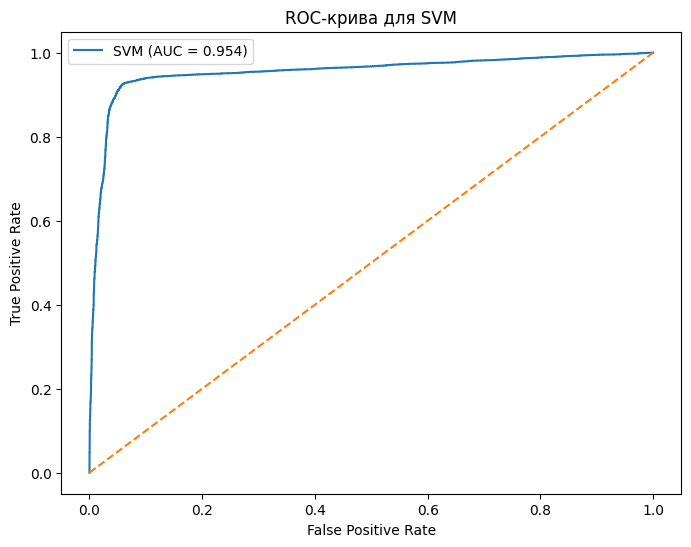

In [193]:
# from sklearn.metrics import roc_curve, roc_auc_score

y_score_svm = clf_svm.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_score_svm)
roc_auc_svm = roc_auc_score(y_test, y_score_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-крива для SVM')
plt.legend()
plt.show()

**Українська версія:**     
ROC-крива моделі «Методу опорних векторів» демонструє високу здатність моделі розрізняти клієнтів, які припинять користуватися послугами, та клієнтів, які залишаться. Значення площі під ROC-кривою (ROC-AUC) становить 0,954, що свідчить про дуже високу якість розділення двох класів. Крива розташована близько до верхнього лівого кута графіка, що означає можливість отримувати високий рівень істинно позитивних прогнозів при відносно низькій частці хибнопозитивних прогнозів. Отже, модель SVM демонструє сильну здатність розпізнавати потенційний відтік клієнтів.   
**English version:**  
The ROC curve of the SVM model demonstrates a high ability to distinguish between customers who are likely to churn and customers who are likely to remain. The area under the ROC curve (ROC-AUC) is 0.954, indicating a very strong ability of the model to separate the two classes. The curve is positioned close to the upper-left corner of the plot, which means that the model can achieve a high true positive rate while maintaining a relatively low false positive rate. Therefore, the SVM model demonstrates strong performance in identifying potential customer churn.

**Українська версія:**     
Позитивні показники відтоку клієнтів за моделлю «Метод опорних векторів» додаються до кінцевого масиву даних для остаточної оцінки (`final_comparison_churn_df`)

**English version:**      
The positive churn metrics of the Support Vector Machine is added to the final dataframe for final evaluation (`final_comparison_churn_df`)

In [177]:
precision_churn_svm = class_report_svm['1']['precision']
recall_churn_svm = class_report_svm['1']['recall']
f1_churn_svm = class_report_svm['1']['f1-score']

final_comparison_churn_df['best_svm_model'] = [acc_svm,loss_svm,precision_churn_svm,recall_churn_svm,
                                                                             f1_churn_svm]
final_comparison_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model,best_svm_model
0,Accuracy,0.923625,0.939260,0.943549,0.932203
1,Loss,0.236446,NaN,NaN,0.236669
2,Precision,0.952437,0.956828,0.955432,0.951799
3,Recall,0.907491,0.932459,0.942072,0.924469
4,F1-Score,0.929421,0.944487,0.948705,0.937935


**Українська версія:**     
Негативні показники відтоку клієнтів, розраховані за моделлю «Метод опорних векторів», додаються до кінцевого масиву даних (`final_comparison_no_churn_df`) для остаточної оцінки 

**English version:**      
The negative churn metrics of the SVM model are added to the final dataframe (`final_comparison_no_churn_df`) for final evaluation

In [178]:
precision_no_churn_svm = class_report_svm['0']['precision']
recall_no_churn_svm = class_report_svm['0']['recall']
f1_no_churn_svm = class_report_svm['0']['f1-score']

final_comparison_no_churn_df['best_svm_model'] = [acc_svm,loss_svm,precision_no_churn_svm,recall_no_churn_svm,
                                                                             f1_no_churn_svm]
final_comparison_no_churn_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model,best_svm_model
0,Accuracy,0.923625,0.939260,0.943549,0.932203
1,Loss,0.236446,NaN,NaN,0.236669
2,Precision,0.891397,0.918634,0.929236,0.909363
3,Recall,0.943677,0.947711,0.945384,0.941815
4,F1-Score,0.916792,0.932946,0.937240,0.925305


**Українська версія:**     
Макросередні показники класифікації моделі «Метод опорних векторів» додаються до кінцевої таблиці даних для порівняння (`final_comparison_macro_df`) з метою остаточної оцінки. 

**English version:**      
The macro-average classification metrics of the SVM model are added to the final comparison dataframe (`final_comparison_macro_df`) for final evaluation.

In [182]:
macro_precision_svm = class_report_svm['macro avg']['precision']
macro_recall_svm = class_report_svm['macro avg']['recall']
macro_f1_svm = class_report_svm['macro avg']['f1-score']

final_comparison_macro_df['best_svm_model'] = [acc_svm,loss_svm,macro_precision_svm,macro_recall_svm,
                                                                             macro_f1_svm]
final_comparison_macro_df

,Metrics,best_logistic_regression_model,best_decision_tree_model,best_random_forest_model,best_svm_model
0,Accuracy,0.923625,0.939260,0.943549,0.932203
1,Loss,0.236446,NaN,NaN,0.236669
2,Precision,0.921917,0.937731,0.942334,0.930581
3,Recall,0.925584,0.940085,0.943728,0.933142
4,F1-Score,0.923107,0.938716,0.942973,0.931620


In [180]:
svm_location = '../models/svm'

os.makedirs(svm_location, exist_ok=True)

model_path_svm = os.path.join(svm_location, 'best_svm_model.pkl')

joblib.dump(best_estimator_svm,model_path_svm)

['../models/svm/best_svm_model.pkl']

## 5. Модель нейронної мережі ( The Neural Network Model)

<!-- import tensorflow as tf

from keras import models
from keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau -->